In [3]:
import os
import xarray as xr
import sys
import itertools
from itertools import zip_longest
from lca_algebraic import initProject
import pandas as pd
import numpy as np
import xarray as xr
import pickle
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.patches as mpatches
plt.rcParams['font.family'] = 'Times New Roman'
plt.style.use('tableau-colorblind10') #seaborn-v0_8-whitegrid

## 1. get LCA DF prepared for ICEV and BEV (here 2*NMC622) 

In [4]:
icev = pd.read_excel('output/ICEV_vlifecycle_finalLCA.xlsx') 
bev = pd.read_excel('output/BEV_vlifecycle_NMC622NMC622finalLCA.xlsx')
print(len(icev),len(bev))

27 27


In [5]:
bev['Powertrain'] = 'BEV'
icev['Powertrain'] = 'ICEV'

In [6]:
icev = icev.rename(columns={'V1A': 'V1AB' }) 
icev.head()

,SSP,v_year,IC,V1AB,F2,V2,Powertrain
0,ssp119,2030,IPCC2021_default,98438.795525,215204.681141,925337.088000,ICEV
1,ssp119,2030,pGWP100,99125.053226,26768.625653,922867.545960,ICEV
2,ssp119,2030,premise_GWP,101192.073576,41166.370829,925337.088000,ICEV
3,ssp119,2040,IPCC2021_default,87588.259380,176013.923959,879070.233600,ICEV
4,ssp119,2040,pGWP100,87556.976391,-480508.620881,876671.642052,ICEV


## plot - one IC (pGWP100) only, BEV vs. ICEV

In [7]:
df = pd.concat([bev, icev], ignore_index=True)
print(len(df))
df = df[df['IC'] == 'pGWP100']
print(len(df))
df

54
18


,SSP,v_year,IC,V1AB,F2,V1B,Powertrain,V2
1,ssp119,2030,pGWP100,179060.507296,29337.701540,62289.142394,BEV,NaN
4,ssp119,2040,pGWP100,148202.722438,6377.565420,47742.074673,BEV,NaN
7,ssp119,2050,pGWP100,128667.065631,9669.330577,47817.552096,BEV,NaN
10,ssp245,2030,pGWP100,194890.342713,325671.695229,64674.538328,BEV,NaN
13,ssp245,2040,pGWP100,169486.722384,170015.279945,51769.758524,BEV,NaN
16,ssp245,2050,pGWP100,150128.288458,75600.105820,52104.975492,BEV,NaN
19,ssp585,2030,pGWP100,206395.980348,378360.595163,80652.352301,BEV,NaN
22,ssp585,2040,pGWP100,195312.396370,434058.017847,73343.646205,BEV,NaN
25,ssp585,2050,pGWP100,168499.878620,447700.485951,74108.759809,BEV,NaN
28,ssp119,2030,pGWP100,99125.053226,26768.625653,NaN,ICEV,922867.545960


In [8]:
df[ (df['SSP'] =='ssp119') & (df['v_year'] ==2030 )] 

,SSP,v_year,IC,V1AB,F2,V1B,Powertrain,V2
1,ssp119,2030,pGWP100,179060.507296,29337.701540,62289.142394,BEV,NaN
28,ssp119,2030,pGWP100,99125.053226,26768.625653,NaN,ICEV,922867.54596


In [9]:
print(832677.228951 + (-858523.524094) +82663.226564  )
print( 128667.065631	+ 9669.330577 +	47817.552096	)

56816.93142100003
186153.94830400002


In [10]:
(186153.94830400002 - 56816.93142100003 ) /  186153.94830400002

0.6947852466270834

### prepare df_list for ploting

In [11]:
df_list = []
for sp in ["ssp119","ssp245","ssp585"]: 
    for vy in [2030,2040,2050]: 
        dd = df [ (df['SSP'] == sp)  & (df['v_year'] == vy)   ]
        df_list.append(dd)

print(len(df_list))
df_list[0]

9


,SSP,v_year,IC,V1AB,F2,V1B,Powertrain,V2
1,ssp119,2030,pGWP100,179060.507296,29337.701540,62289.142394,BEV,NaN
28,ssp119,2030,pGWP100,99125.053226,26768.625653,NaN,ICEV,922867.54596


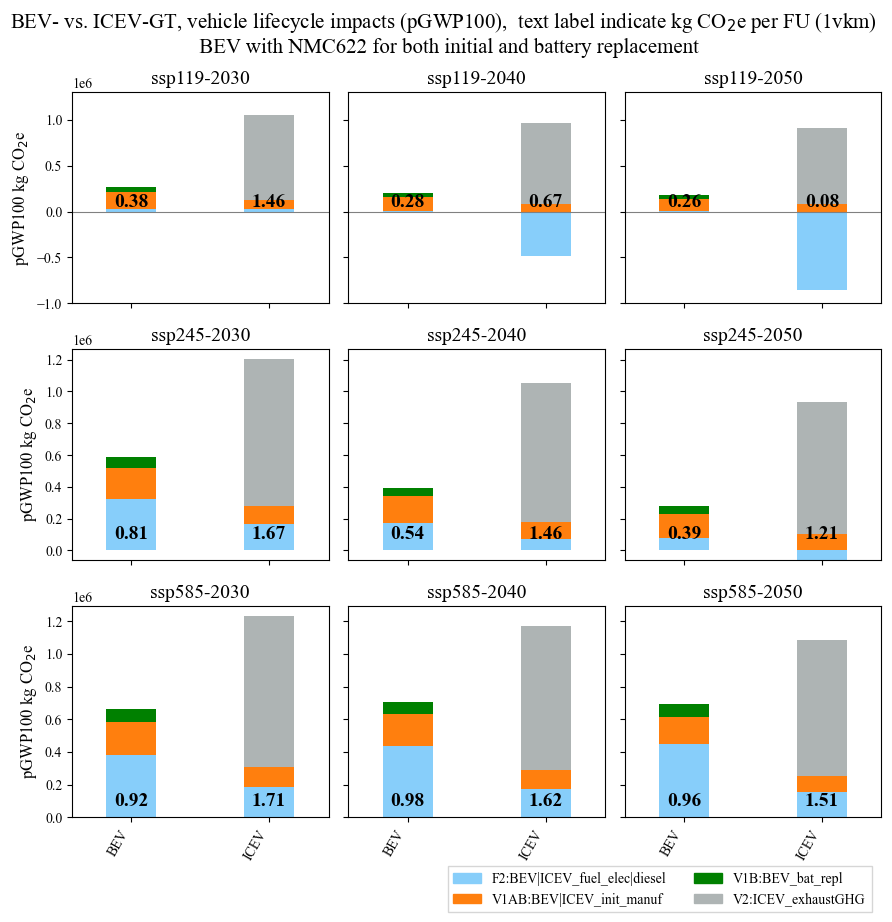

In [13]:
color_dict = {
    'F2':  'lightskyblue',   # 
    'V1AB': '#ff7f0e',  # Orange
    'V1B': 'green',   #green
    'V2': '#aeb4b4',   # Medium gray
}
FU = 20*36000

fig, axs = plt.subplots(3, 3, figsize=(9, 9), sharey='row')
axs = axs.flatten()

for i in range(len(df_list)) :
    ax = axs[i]
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    axs[i].grid(True, linestyle='--', linewidth=0.5, color='gray')
    df = df_list[i]
    ddf = df[[ 'Powertrain', 'IC', 'V1AB', 'F2', 'V1B', 'V2']]  
    pivot_df = ddf.pivot_table(index='Powertrain', columns='IC', values= [ 'V1AB', 'F2', 'V1B', 'V2'  ] ) 
    colors = [color_dict[col[0]] for col in pivot_df.columns]
    subtitle =  str(df["SSP"].values[0]) + "-" + str(df["v_year"].values[0] )
    pivot_df.plot(kind='bar', ax=ax, stacked=True, legend=False, color=colors, title =subtitle, width=0.36, xlabel='' )
    axs[i].set_title(subtitle, fontsize = 14)


    columns_to_sum = ['V1AB', 'F2', 'V1B', 'V2']  
    bev_final_lca =  ddf[columns_to_sum].sum(axis=1).values[0] 
    icev_final_lca = ddf[columns_to_sum].sum(axis=1).values[1] 
    bev_lca_perfu = bev_final_lca / FU 
    icev_final_perfu = icev_final_lca / FU
    axs[i].text(0, 1e5, f'{bev_lca_perfu:.2f}', 
                ha='center', va='center', fontsize=14, fontweight='bold', color='black')
    axs[i].text(1, 1e5, f'{icev_final_perfu:.2f}', 
                ha='center', va='center', fontsize=14, fontweight='bold', color='black')

    # for ylables
    if i % 3 != 0:
        axs[i].set_ylabel('') 
    else: 
        axs[i].set_ylabel(r'pGWP100 kg CO$_2$e', fontsize = 12)

    
   
    if i == 0  or i == 1 or i == 2 :   
        axs[i].set_ylim(-1e6, 1.3e6)
        axs[i].axhline(y=0, color='gray', linewidth=0.8)
        #axs[i].grid(True, linestyle='--', linewidth=0.5, color='gray')

    # same y-label for same SSP: not needed as  sharey='row' 
    """ 
    elif i == 3  or i == 4 or i == 5 :   
        axs[i].set_ylim(0, 1.3e6 )
        #axs[i].grid(True, linestyle='--', linewidth=0.5, color='gray')
    else  :   
        axs[i].set_ylim(0, 1.3e6 )
        #axs[i].grid(True, linestyle='--', linewidth=0.5, color='gray')
    """
    
    # for xlables    
    if i<6:
        axs[i].set_xticklabels([])  
        axs[i].set_xlabel('') 
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')

    
    
    # for xlables    
    if i<6:
        axs[i].set_xticklabels([])  
        axs[i].set_xlabel('') 
    else:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')


# Add labels and title:   
fig.suptitle('BEV- vs. ICEV-GT, vehicle lifecycle impacts (pGWP100),  text label indicate kg CO$_2$e per FU (1vkm)  \n BEV with NMC622 for both initial and battery replacement', fontsize=15)
handles = [mpatches.Patch(color=color_dict['F2'], label='F2:BEV|ICEV_fuel_elec|diesel'),
           mpatches.Patch(color=color_dict['V1AB'], label='V1AB:BEV|ICEV_init_manuf'),
           mpatches.Patch(color=color_dict['V1B'], label='V1B:BEV_bat_repl'),
           mpatches.Patch(color=color_dict['V2'], label='V2:ICEV_exhaustGHG') 
          ]


fig.legend(handles=handles, loc='lower right', bbox_to_anchor=(0.98, -0.03), fancybox=False, ncol=2)


fig.supxlabel('') #Impact Category
plt.tight_layout()
plt.show()
fig.savefig('output_plot/bev_NMC622NMC622_vs_icev.png',bbox_inches='tight')

####  test plot DO NOT RUN - premise_gwp & pGWP100 as two IC, also for BEV vs. ICEB

<Axes: >

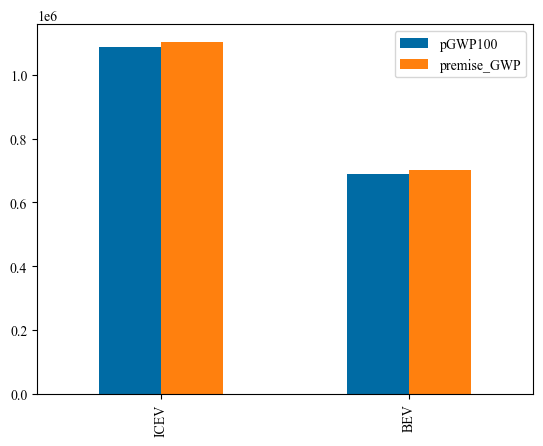

In [136]:
data = {
    'Powertrain': ['BEV', 'BEV', 'BEV', 'BEV', 'ICEV', 'ICEV', 'ICEV', 'ICEV'],
    'IC': ['F2', 'V1AB', 'V1B', 'V2', 'F2', 'V1AB', 'V1B', 'V2'],
    'pGWP100': [447700.485951, 168499.878620, 74108.759809, np.nan, 157080.552119, 96562.311548, np.nan, 833920.833767],
    'premise_GWP': [454234.464293, 171446.890473, 75496.805002, np.nan, 169406.240987, 98170.079895, np.nan, 835116.72192]
}

# Create DataFrame
df = pd.DataFrame(data)

# Pivot table
pivot_df = df.pivot_table(index='Powertrain', columns='IC', values=['pGWP100', 'premise_GWP'], aggfunc='sum')
pivot_df



plot_data = {
    'ICEV': {
        'pGWP100': pivot_df['pGWP100'].loc['ICEV'].dropna().sum(),
        'premise_GWP': pivot_df['premise_GWP'].loc['ICEV'].dropna().sum()
    },
    'BEV': {
        'pGWP100': pivot_df['pGWP100'].loc['BEV'].dropna().sum(),
        'premise_GWP': pivot_df['premise_GWP'].loc['BEV'].dropna().sum()
    }
}

# Convert to DataFrame for plotting
plot_df = pd.DataFrame(plot_data)
plot_df


# Plotting
fig, ax = plt.subplots()
plot_df.T.plot(kind='bar', stacked=False, ax=ax)


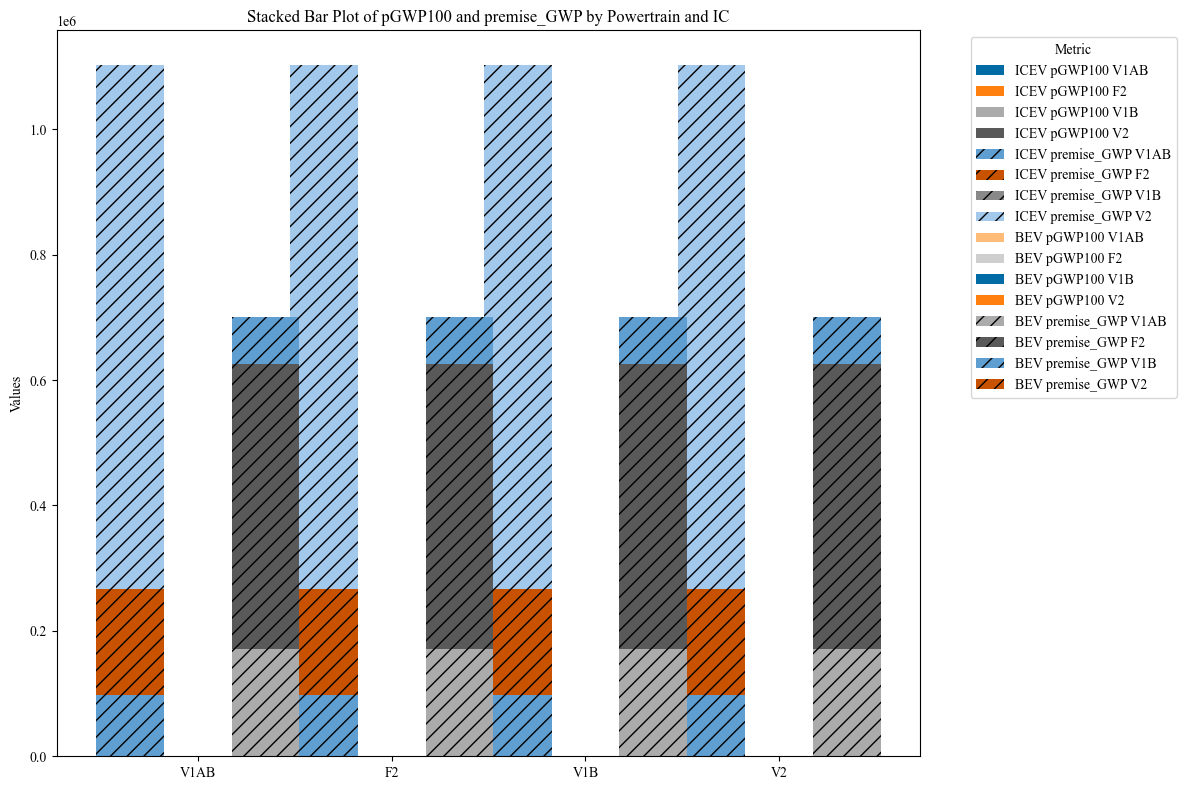

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample data
data = {
    'Powertrain': ['BEV', 'BEV', 'BEV', 'BEV', 'ICEV', 'ICEV', 'ICEV', 'ICEV'],
    'IC': ['F2', 'V1AB', 'V1B', 'V2', 'F2', 'V1AB', 'V1B', 'V2'],
    'pGWP100': [447700.485951, 168499.878620, 74108.759809, np.nan, 157080.552119, 96562.311548, np.nan, 833920.833767],
    'premise_GWP': [454234.464293, 171446.890473, 75496.805002, np.nan, 169406.240987, 98170.079895, np.nan, 835116.72192]
}

# Create DataFrame
df = pd.DataFrame(data)

# Pivot table
pivot_df = df.pivot_table(index='Powertrain', columns='IC', values=['pGWP100', 'premise_GWP'], aggfunc='sum')

# Extract the data for plotting
icev_pGWP100 = pivot_df['pGWP100'].loc['ICEV'].fillna(0)
icev_premise_GWP = pivot_df['premise_GWP'].loc['ICEV'].fillna(0)
bev_pGWP100 = pivot_df['pGWP100'].loc['BEV'].fillna(0)
bev_premise_GWP = pivot_df['premise_GWP'].loc['BEV'].fillna(0)

# Indices for bar groups
variables = ['V1AB', 'F2', 'V1B', 'V2']
indices = np.arange(len(variables))

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))
width = 0.35

# Plot ICEV
icev_bottom = np.zeros(len(indices))
for var in variables:
    ax.bar(indices - width, icev_pGWP100[var], width, bottom=icev_bottom, label=f'ICEV pGWP100 {var}')
    icev_bottom += icev_pGWP100[var]

icev_bottom = np.zeros(len(indices))
for var in variables:
    ax.bar(indices - width, icev_premise_GWP[var], width, bottom=icev_bottom, label=f'ICEV premise_GWP {var}', hatch='//')
    icev_bottom += icev_premise_GWP[var]

# Plot BEV
bev_bottom = np.zeros(len(indices))
for var in variables:
    ax.bar(indices + width, bev_pGWP100[var], width, bottom=bev_bottom, label=f'BEV pGWP100 {var}')
    bev_bottom += bev_pGWP100[var]

bev_bottom = np.zeros(len(indices))
for var in variables:
    ax.bar(indices + width, bev_premise_GWP[var], width, bottom=bev_bottom, label=f'BEV premise_GWP {var}', hatch='//')
    bev_bottom += bev_premise_GWP[var]

# Customizing the plot
ax.set_ylabel('Values')
ax.set_title('Stacked Bar Plot of pGWP100 and premise_GWP by Powertrain and IC')
ax.set_xticks(indices)
ax.set_xticklabels(variables)
ax.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### HTML, facet by each SSP/MY

In [15]:
df =  pd.concat([bev, icev], ignore_index=True)
df = df[df['IC'] == 'pGWP100']
columns_to_sum = ['V1AB', 'F2', 'V1B', 'V2']
df['LC_kgCO2e_vkm'] = round( df[columns_to_sum].sum(axis=1) / (36000*20) ,2)
df.head()
#need to reindex dataframe, for plotly annotation subplot location
df.reset_index(drop=True, inplace=True)
#df2

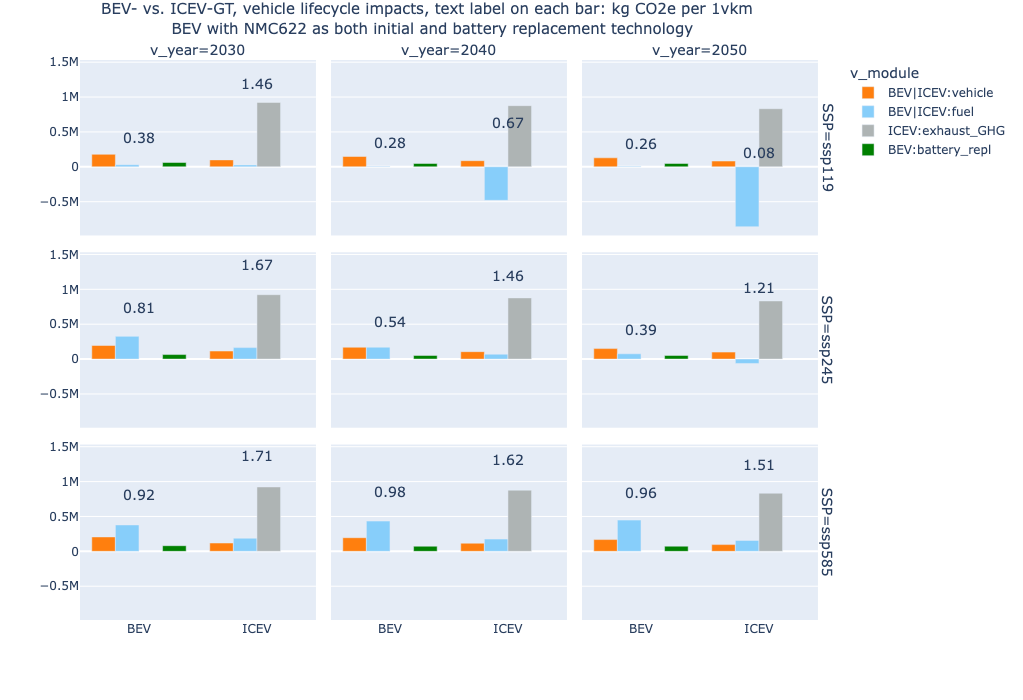

In [19]:
import plotly.express as px

tt1 = f'BEV- vs. ICEV-GT, vehicle lifecycle impacts, text label on each bar: kg CO2e per 1vkm '
tt2 = f' BEV with NMC622 as both initial and battery replacement technology'

color_dict = {
    'F2':  'lightskyblue',   # 
    'V1AB': '#ff7f0e',  # Orange
    'V1B': 'green',   #green
    'V2': '#aeb4b4',   # Medium gray
}

custom_labels = {
    'F2': 'BEV|ICEV:fuel',
    'V1AB': 'BEV|ICEV:vehicle',
    'V1B': 'BEV:battery_repl',
    'V2': 'ICEV:exhaust_GHG'
}


fig = px.bar(df, x="Powertrain", y= [ 'V1AB', 'F2', 'V2', 'V1B'],   
            #text='LC_kgCO2e_vkm' ,  # not working, using below annotation 
            barmode="group",   #stack,  if using stack, negative value on F2 messed up, tried with add_trace, not working
            color_discrete_map=color_dict,
            facet_row="SSP", facet_col="v_year"
            )


# to add text label on top of each bar (at location, y_sum)
for i in df.index:
    y_sum = df.loc[i, ['V1AB', 'F2', 'V2', 'V1B']].sum()
    x = df.loc[i, 'Powertrain']
    year = df.loc[i, 'v_year']
    ssp = df.loc[i, 'SSP']
    text = df.loc[i, 'LC_kgCO2e_vkm']
    # Determine the correct row and column based on 'v_year' and 'SSP'
    col = 1 if year == 2030 else 2 if year == 2040 else 3
    row = 3 if ssp == 'ssp119' else 2 if ssp == 'ssp245' else 1
    fig.add_annotation(x=x, y=y_sum, text=f'{text}',
                       showarrow=False,
                       xanchor='center',
                       yanchor='bottom',
                       row=row, col=col)


for trace in fig.data:
    trace.name = custom_labels[trace.name]


# Update layout 
fig.update_layout(    
    annotations=[dict(font_size=14)], 
    legend_title_text='v_module',
    title={
        'text': f"{tt1}<br>{tt2}",
        'y': 0.98,  # 
        'x': 0.42,   # Center the title
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 15}  # Font size for tt1
    },
    width=900,  # Width of the entire figure in pixels
    height=700,  # Height of the entire figure in pixels
)


# do not use value as y-label , yaxis=dict(title='pGWP100 CO$_2$e') not working  will change whole plot format
fig.update_yaxes(title_text='', matches='y')
fig.update_xaxes(title_text='', matches='x')
#fig.update_layout(yaxis=dict(title='pGWP100 CO$_2$e'))

# Show the figure
fig.show()
fig.write_html("output_plot/bev_NMC622NMC622_vs_icev.html")


#### postive and negative value messed up 

In [ ]:
df =  pd.concat([bev, icev], ignore_index=True)
df = df[df['IC'] == 'pGWP100']
columns_to_sum = ['V1AB', 'F2', 'V1B', 'V2']
df['LC_kgCO2e_vkm'] = round( df[columns_to_sum].sum(axis=1) / (36000*20) ,2)
df.head()

#need to reindex dataframe, for plotly annotation subplot location
df.reset_index(drop=True, inplace=True)
#df2

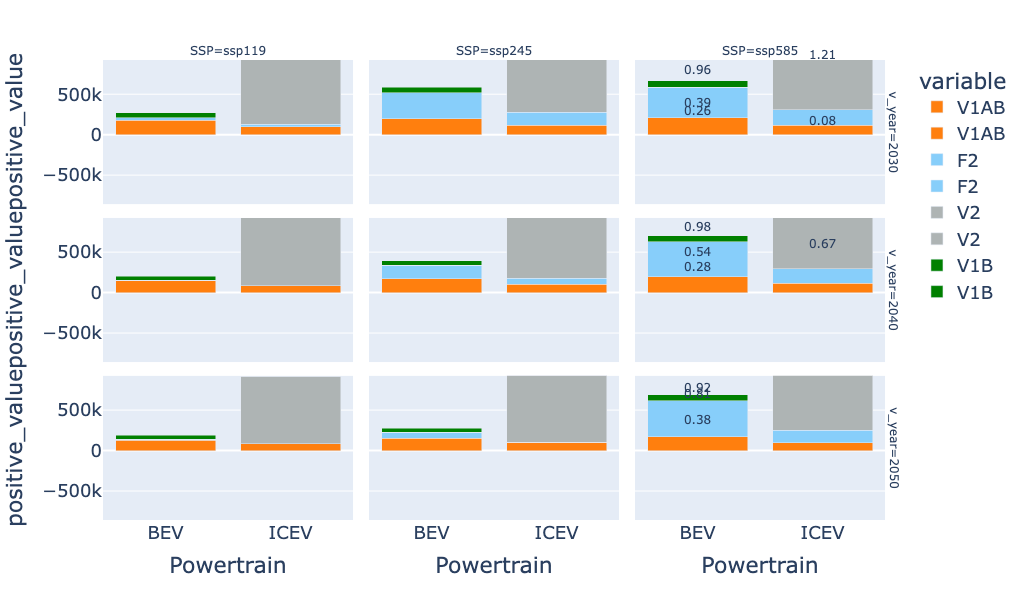

In [123]:
# Melt the DataFrame to have a long-form data format
# Melt the DataFrame to have a long-form data format
df_melted = df.melt(id_vars=['Powertrain', 'v_year', 'SSP', 'LC_kgCO2e_vkm'], 
                    value_vars=['V1AB', 'F2', 'V2', 'V1B'],
                    var_name='variable', value_name='value')

# Split into positive and negative values
df_melted['positive_value'] = df_melted['value'].apply(lambda x: x if x >= 0 else 0)
df_melted['negative_value'] = df_melted['value'].apply(lambda x: x if x < 0 else 0)

# Calculate the minimum y-value for setting the y-axis range
min_y_value = df_melted['negative_value'].min()

# Create the figure with positive values
fig = px.bar(df_melted, x="Powertrain", y="positive_value", color="variable",
             color_discrete_map=color_dict,
             barmode="stack",
             facet_row="v_year", facet_col="SSP",
             height=600, width=800)

# Add negative values as a separate trace
for variable in df_melted['variable'].unique():
    negative_trace = px.bar(df_melted[df_melted['variable'] == variable], 
                            x="Powertrain", y="negative_value", color="variable",
                            color_discrete_map=color_dict,
                            barmode="stack",
                            facet_row="v_year", facet_col="SSP").data[0]
    fig.add_trace(negative_trace)

# Calculate the 

# Adjust y-axis to accommodate negative values
fig.update_yaxes(range=[min_y_value, df_melted['positive_value'].max()])

# Increase facet row and facet column label font sizes
fig.update_layout(
    font=dict(
        size=18  # Adjust the font size as needed
    ),
    annotations=[dict(font_size=12)]
)


fig.show()

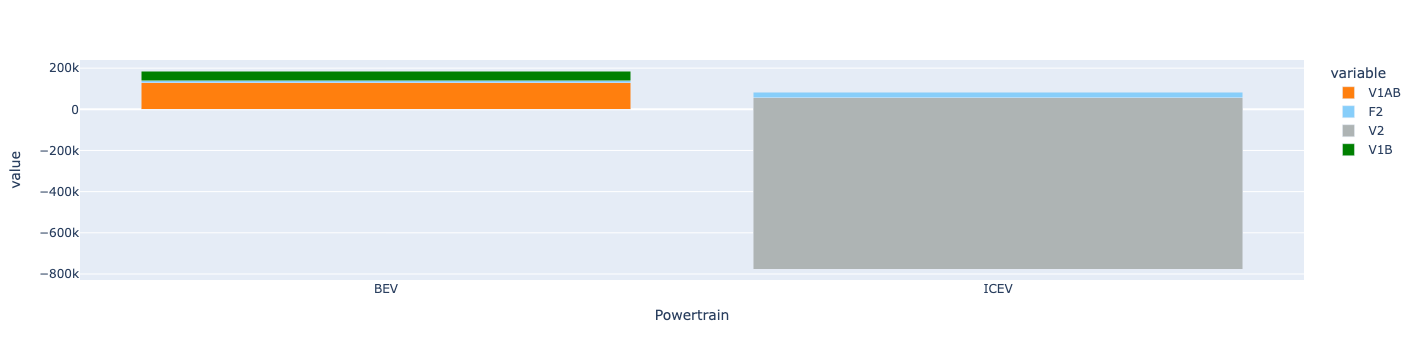

In [118]:


fig = px.bar(df_list[2], x="Powertrain", y= [ 'V1AB', 'F2', 'V2', 'V1B'],   
            #text='LC_kgCO2e_vkm' ,  # not working, using below annotation 
            barmode="stack",
            color_discrete_map=color_dict
            #facet_row="SSP", facet_col="v_year"
            )

fig.show()


#### SSP585 have higher impacts on grid elec for future years because: 

- inventory side, QC grid elec has higher impacts for future years   
- LCIA side, also higher GWP for future years, under SSP585


In [14]:
bev[ (bev['SSP'] == 'ssp585' ) & (bev['IC'] == 'pGWP100' )  ]

,SSP,v_year,IC,V1AB,F2,V1B,Powertrain
19,ssp585,2030,pGWP100,206395.980348,378360.595163,80652.352301,BEV
22,ssp585,2040,pGWP100,195312.396370,434058.017847,73343.646205,BEV
25,ssp585,2050,pGWP100,168499.878620,447700.485951,74108.759809,BEV


In [15]:
bev[ (bev['SSP'] == 'ssp585' ) & (bev['IC'] == 'premise_GWP' )  ]

,SSP,v_year,IC,V1AB,F2,V1B,Powertrain
20,ssp585,2030,premise_GWP,212768.722460,386423.074807,83235.227514,BEV
23,ssp585,2040,premise_GWP,200824.046621,443346.944189,75496.805002,BEV
26,ssp585,2050,premise_GWP,171446.890473,454234.464293,75496.805002,BEV
